In [6]:
import os

# Path to your dataset folder in Kaggle
# what dataset files are available and understand our dataset files 
DATA_PATH = "/kaggle/input/jazbatai-data"

# List all files in the directory
files = [f for f in os.listdir(DATA_PATH) if os.path.isfile(os.path.join(DATA_PATH, f))]
files = files[:5]  # take only first 5

print("Found files:", files)

def count_sentences_blank_line(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        content = f.read()
    # Data in each Split by double newlines (blank lines)
    sentences = [s.strip() for s in content.split("\n\n") if s.strip()]

    return len(sentences)
    
# Process each file
for file_name in files:
    full_path = os.path.join(DATA_PATH, file_name)
    
    num_sentences = count_sentences_blank_line(full_path)
    
    print(f"File: {file_name}")
    print(f"Number of sentences (blank-line separated): {num_sentences}")
    print("--------------------------------------------")


Found files: ['training_data_sarcasam.txt', 'training_data_joy.txt', 'training_data_anger.txt', 'training_data_sadness.txt', 'training_data_neutral.txt']
File: training_data_sarcasam.txt
Number of sentences (blank-line separated): 932
--------------------------------------------
File: training_data_joy.txt
Number of sentences (blank-line separated): 1529
--------------------------------------------
File: training_data_anger.txt
Number of sentences (blank-line separated): 999
--------------------------------------------
File: training_data_sadness.txt
Number of sentences (blank-line separated): 1110
--------------------------------------------
File: training_data_neutral.txt
Number of sentences (blank-line separated): 1031
--------------------------------------------


In [7]:
# Import all necessary libraries
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os
import time
import re
import string
from sklearn.preprocessing import LabelEncoder

# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
def load_jazbatAI_data():
   # Load all emotion files from JazbatAI_data dataset and split into train/test
   
    data = []
    labels = []
    
    # Define all your emotion files
    emotion_files = {
        'training_data_anger.txt': 'anger',
        'training_data_joy.txt': 'joy', 
        'training_data_sadness.txt': 'sadness',
        'training_data_sarcasam.txt': 'sarcasm',
        'training_data_neutral.txt': 'neutral'
    }
    
    print("🔄 Loading emotion data...")
    # Load data from each emotion file
    for file_name, emotion in emotion_files.items():
        try:
            file_path = f'/kaggle/input/jazbatai-data/{file_name}'
            if os.path.exists(file_path):
                with open(file_path, 'r', encoding='utf-8') as f:
                    lines = [line.strip() for line in f.readlines() if line.strip()]
                
                # Add all samples with their emotion label
                data.extend(lines)
                labels.extend([emotion] * len(lines))
                print(f"   ✅ {file_name}: {len(lines)} samples loaded as '{emotion}'")
            else:
                print(f"   ❌ {file_name}: File not found")
        except Exception as e:
            print(f"   ❌ Error loading {file_name}: {e}")
    
    return data, labels

# Load the complete dataset
print("🚀 Starting data loading process...")
texts, emotions = load_jazbatAI_data()

# Create DataFrame
df = pd.DataFrame({
    'text': texts,
    'emotion': emotions
})

print(f"\n📊 Dataset Summary:")
print(f"   Total samples: {len(df)}")
print(f"   Emotions distribution:")
emotion_counts = df['emotion'].value_counts()
for emotion, count in emotion_counts.items():
    print(f"      {emotion}: {count} samples")

🚀 Starting data loading process...
🔄 Loading emotion data...
   ✅ training_data_anger.txt: 999 samples loaded as 'anger'
   ✅ training_data_joy.txt: 1529 samples loaded as 'joy'
   ✅ training_data_sadness.txt: 1110 samples loaded as 'sadness'
   ✅ training_data_sarcasam.txt: 932 samples loaded as 'sarcasm'
   ✅ training_data_neutral.txt: 1031 samples loaded as 'neutral'

📊 Dataset Summary:
   Total samples: 5601
   Emotions distribution:
      joy: 1529 samples
      sadness: 1110 samples
      neutral: 1031 samples
      anger: 999 samples
      sarcasm: 932 samples


In [9]:
# Data verifying giving sample data from each emotion and checking for any missing data
print("🔍 Data Exploration:")
print(f"\n📝 Sample texts from each emotion:")
for emotion in df['emotion'].unique():
    samples = df[df['emotion'] == emotion]['text'].head(3)
    print(f"\n{emotion.upper()}:")
    for i, sample in enumerate(samples):
        print(f"   {i+1}. {sample}")


🔍 Data Exploration:

📝 Sample texts from each emotion:

ANGER:
   1. Mujhe samajh nahi aata log itne laaparwah kyun hote hain.
   2. jis tarah usne baat ki, mera pura din barbaad ho gaya.
   3. Ye constant disrespect dekh kar waqai gussa control nahi hota.

JOY:
   1. excellent i like it and going to purchase one more
   2. zabardast...dera maza ba oki...
   3. pros great key and rgb cons build quality is cheaper an less than expected at this price but it decent

SADNESS:
   1. ye kia tareeka ha per order 1 kg potato only , agr aplog k halat kharab hain tu company bund kardo bhai logo ko pareshan kq kr rahe ho , is tarha per order per kg not acceptable
   2. they never told & mention that how much alcohol % used on that sanitizer, worst sanitizer i've ever purchase ! never recommended !, who recommends minimum 60%
   3. hukumat ne sugar mil malikan ko qematein kam karne par majbor nahin kiya balke neb ne tehqiqat karana chahi to sadar perviz musharaf ke humum par ise bhi rok deya gaya 

In [10]:
# Data Preprocessing
print("🛠️ Preparing data for training...")

def clean_roman_urdu_text(text):
    """
    Clean Roman Urdu text by removing garbage characters, extra spaces, etc.
    """
    if not isinstance(text, str):
        return ""
    
    # Remove Unicode characters and garbage text
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)  # Remove non-ASCII characters
    text = re.sub(r'ï¿½+', ' ', text)  # Remove specific garbage characters
    text = re.sub(r'[�]+', ' ', text)  # Remove replacement characters
    
    # Remove special characters but keep basic punctuation
    text = re.sub(r'[^\w\s\.!?]', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text)
    
    # Remove leading/trailing whitespace
    text = text.strip()
    
    return text
    
# Clean data - remove any empty texts
df = df[df['text'].str.strip() != '']
df = df.dropna()

# Apply text cleaning
print("🧹 Cleaning text data...")
df['text_cleaned'] = df['text'].apply(clean_roman_urdu_text)

# Remove any texts that became empty after cleaning
df = df[df['text_cleaned'].str.strip() != '']

print(f"   Samples after cleaning: {len(df)}")

# Show cleaning examples
print(f"\n📝 Text Cleaning Examples:")
print("=" * 80)
for i in range(min(3, len(df))):
    original_text = df.iloc[i]['text']
    cleaned_text = df.iloc[i]['text_cleaned']
    if original_text != cleaned_text:  # Only show if cleaning made a difference
        print(f"Sample {i+1}:")
        print(f"   Original: {original_text[:100]}...")
        print(f"   Cleaned:  {cleaned_text[:100]}...")
        print("-" * 80)
# Show cleaning examples 2
print(f"\n📝 Text Cleaning Examples:")
print("=" * 90)
for i in range(min(10, len(df))):
    original_text = df.iloc[i]['text']
    cleaned_text = df.iloc[i]['text_cleaned']
    if original_text != cleaned_text:  # Only show if cleaning made a difference
        print(f"Sample {i+1}:")
        print(f"   Original: {original_text[:100]}...")
        print(f"   Cleaned:  {cleaned_text[:100]}...")
        print("-" * 80)

🛠️ Preparing data for training...
🧹 Cleaning text data...
   Samples after cleaning: 5599

📝 Text Cleaning Examples:
Sample 2:
   Original: jis tarah usne baat ki, mera pura din barbaad ho gaya....
   Cleaned:  jis tarah usne baat ki mera pura din barbaad ho gaya....
--------------------------------------------------------------------------------

📝 Text Cleaning Examples:
Sample 2:
   Original: jis tarah usne baat ki, mera pura din barbaad ho gaya....
   Cleaned:  jis tarah usne baat ki mera pura din barbaad ho gaya....
--------------------------------------------------------------------------------
Sample 4:
   Original: Har dafa wohi bakwaas repeat hoti hai, aur ab hadd ho chuki hai....
   Cleaned:  Har dafa wohi bakwaas repeat hoti hai aur ab hadd ho chuki hai....
--------------------------------------------------------------------------------
Sample 5:
   Original: Kisi ko bhi zimmedari ka sense nahi, aur blame phir mujh par aa jata hai....
   Cleaned:  Kisi ko bhi zimmedari ka se

In [11]:
# Data Preprocessing finalee

# Convert emotions to numerical labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['emotion'])
X_cleaned = df['text_cleaned']  # Use cleaned text
X_original = df['text']         # Keep original for reference

print("✅ Emotion label mapping:")
for i, emotion in enumerate(label_encoder.classes_):
    print(f"   {i}: {emotion}")

# Split data into training and testing sets (80% train, 20% test)
X_train_cleaned, X_test_cleaned, y_train, y_test = train_test_split(
    X_cleaned, y, test_size=0.2, random_state=42, stratify=y
)

# Also keep original split for comparison
X_train_original, X_test_original, _, _ = train_test_split(
    X_original, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📈 Data Split Summary:")
print(f"   Training samples: {len(X_train_cleaned)}")
print(f"   Testing samples: {len(X_test_cleaned)}")
print(f"   Total samples: {len(X_cleaned)}")

# Show training distribution
train_distribution = pd.Series(y_train).value_counts().sort_index()
train_distribution.index = label_encoder.inverse_transform(train_distribution.index)
print(f"\n🏋️ Training set distribution:")
for emotion, count in train_distribution.items():
    print(f"   {emotion}: {count} samples")
    
# Show testing distribution
test_distribution = pd.Series(y_test).value_counts().sort_index()
test_distribution.index = label_encoder.inverse_transform(test_distribution.index)
print(f"\n🧪 Testing set distribution:")
for emotion, count in test_distribution.items():
    print(f"   {emotion}: {count} samples")


✅ Emotion label mapping:
   0: anger
   1: joy
   2: neutral
   3: sadness
   4: sarcasm

📈 Data Split Summary:
   Training samples: 4479
   Testing samples: 1120
   Total samples: 5599

🏋️ Training set distribution:
   anger: 799 samples
   joy: 1221 samples
   neutral: 825 samples
   sadness: 888 samples
   sarcasm: 746 samples

🧪 Testing set distribution:
   anger: 200 samples
   joy: 306 samples
   neutral: 206 samples
   sadness: 222 samples
   sarcasm: 186 samples


In [12]:
# Defining Roman Urdu Stop Words 
roman_urdu_stop_words = [
    "hai", "hain", "han", "ho", "hun", "h", "tha", "thi", "thay", "the",
    "ga", "gi", "ge", "raha", "rahi", "rahay", "rha", "rhi", "rahi", "rahe",
    "ka", "ki", "ke", "k", "ko", "ne", "se", "sy", "par", "pe", "pr", "per",
    "mein", "me", "mn", "men", "aur", "or", "ao", "bhi", "bh", "to", "toh",
    "liye", "lye", "main", "men", "mjhy", "mujhe", "hum", "hamein", "ham",
    "tum", "tu", "ap", "aap", "wo", "woh", "us", "iss", "is", "jo", "jis",
    "ye", "yeh", "apna", "apni", "apne", "kar", "kr", "karna", "krna", "kya",
    "hona", "ho", "hue", "huway", "gaya", "gye", "gai", "gay", "wala", "walay", "wali",
    "sakta", "sakti", "sakte", "wese", "bus", "bas", "hi", "b", "tha", "thi",
    "lekin", "magar", "agar", "kyun", "ky", "kyn", "jaisa", "jaise", "jese",
    "sath", "saath", "agar", "agr", "jab", "jb", "tab", "tb", "to", "tu",
    "bht", "bohat", "bahut", "zyada", "zada", "bilkul", "bilkul", "sirf",
    "shayad", "shaed", "q", "kya", "kia", "kon", "kaun", "koun"
]

# Combining with English stop words
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
final_stop_words = list(ENGLISH_STOP_WORDS.union(set(roman_urdu_stop_words)))

print(f"Using {len(final_stop_words)} stop words total")
print(f"   English stop words: {len(ENGLISH_STOP_WORDS)}")
print(f"   Roman Urdu stop words: {len(roman_urdu_stop_words)}")

Using 430 stop words total
   English stop words: 318
   Roman Urdu stop words: 129


In [13]:
# Feature Extraction with TF-IDF word embedding using it text to numbers 
print("Creating TF-IDF features...")

start_time = time.time()

tfidf = TfidfVectorizer(
    max_features=10000,     # Increased features for better performance
    ngram_range=(1, 3),     # Use unigrams, bigrams, and trigrams
    min_df=2,               # Ignore terms that appear in less than 2 documents
    max_df=0.95,            # Ignore terms that appear in more than 95% of documents
    stop_words=final_stop_words,  # USE STOP WORDS HERE!
    sublinear_tf=True,      # Apply sublinear tf scaling
    analyzer='word'
)

# Use cleaned text for training
X_train_tfidf = tfidf.fit_transform(X_train_cleaned)
X_test_tfidf = tfidf.transform(X_test_cleaned)

tfidf_time = time.time() - start_time

print("✅ TF-IDF Feature Extraction Complete!")
print(f"   Vocabulary size: {len(tfidf.vocabulary_)}")
print(f"   Training features shape: {X_train_tfidf.shape}")
print(f"   Testing features shape: {X_test_tfidf.shape}")
print(f"   Time taken: {tfidf_time:.2f} seconds")

Creating TF-IDF features...
✅ TF-IDF Feature Extraction Complete!
   Vocabulary size: 9126
   Training features shape: (4479, 9126)
   Testing features shape: (1120, 9126)
   Time taken: 0.37 seconds


In [14]:
# SVM Model Training
print(" Training SVM Model...")

start_time = time.time()

# Initialize SVM model with optimal parameters for text classification
svm_model = svm.SVC(
    kernel='linear',        # Linear kernel works best for text data
    C=1.0,                  # Regularization parameter
    random_state=42,
    probability=True,       # Enable probability estimates
    class_weight='balanced' # Handle class imbalance
)

# Train the model
svm_model.fit(X_train_tfidf, y_train)

training_time = time.time() - start_time

print("✅ SVM Model Training Complete!")
print(f"   Training time: {training_time:.2f} seconds")
print(f"   Model type: {type(svm_model).__name__}")
print(f"   Kernel: {svm_model.kernel}")

 Training SVM Model...
✅ SVM Model Training Complete!
   Training time: 13.19 seconds
   Model type: SVC
   Kernel: linear


In [15]:

from sklearn.metrics import precision_score, recall_score
# Model Evaluation
print("📊 Evaluating SVM Model...")

# Make predictions
start_time = time.time()
y_pred = svm_model.predict(X_test_tfidf)
y_pred_proba = svm_model.predict_proba(X_test_tfidf)
inference_time = time.time() - start_time

# Calculate inference speed (sentences per second)
inference_speed = len(X_test_cleaned) / inference_time

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
classification_rep = classification_report(y_test, y_pred, target_names=label_encoder.classes_)

print("🎯 MODEL PERFORMANCE RESULTS:")
print("=" * 60)
print(f"📈 Accuracy: {accuracy * 100:.2f}%")
print(f"⭐ Weighted F1-Score: {f1:.4f}")
print(f"🎯 Weighted Precision: {precision:.4f}")
print(f"📋 Weighted Recall: {recall:.4f}")
print(f"⏱️ Training Time: {training_time:.2f} seconds")
print(f"⚡ Inference Speed: {inference_speed:.0f} sentences/second")
print(f"📊 Test Samples: {len(X_test_cleaned)}")
print("=" * 60)

print("\n📋 Detailed Classification Report:")
print(classification_rep)

📊 Evaluating SVM Model...
🎯 MODEL PERFORMANCE RESULTS:
📈 Accuracy: 86.79%
⭐ Weighted F1-Score: 0.8678
🎯 Weighted Precision: 0.8692
📋 Weighted Recall: 0.8679
⏱️ Training Time: 13.19 seconds
⚡ Inference Speed: 1491 sentences/second
📊 Test Samples: 1120

📋 Detailed Classification Report:
              precision    recall  f1-score   support

       anger       0.89      0.85      0.87       200
         joy       0.89      0.88      0.89       306
     neutral       0.88      0.93      0.90       206
     sadness       0.80      0.86      0.83       222
     sarcasm       0.88      0.81      0.84       186

    accuracy                           0.87      1120
   macro avg       0.87      0.87      0.87      1120
weighted avg       0.87      0.87      0.87      1120



In [20]:
# Test Model on Sample Sentences
print("🧪 Testing Model on Sample Sentences:")
print("=" * 70)

def predict_emotion_detailed(text):
    """Predict emotion for a single text with detailed analysis"""
    # Clean the input text
    cleaned_text = clean_roman_urdu_text(text)
    
    # Transform text to TF-IDF
    text_tfidf = tfidf.transform([cleaned_text])
    
    # Predict
    prediction = svm_model.predict(text_tfidf)
    probabilities = svm_model.predict_proba(text_tfidf)[0]
    
    # Get results
    emotion = label_encoder.inverse_transform(prediction)[0]
    confidence = probabilities[prediction[0]]
    
    # Create results dictionary
    results = {
        'original_text': text,
        'cleaned_text': cleaned_text,
        'predicted_emotion': emotion,
        'confidence': confidence,
        'all_probabilities': {
            label_encoder.classes_[i]: prob for i, prob in enumerate(probabilities)
        },
        'top_features': get_top_features_for_text(cleaned_text, emotion)
    }
    
    return results

def get_top_features_for_text(text, predicted_emotion):
    """Get top contributing features for the prediction"""
    emotion_idx = list(label_encoder.classes_).index(predicted_emotion)
    feature_names = tfidf.get_feature_names_out()
    
    # Transform text and get feature values
    text_tfidf = tfidf.transform([text])
    feature_values = text_tfidf.toarray()[0]
    
    # Get model coefficients for this emotion
    if hasattr(svm_model, 'coef_'):
        coef_array = svm_model.coef_.toarray()
        emotion_coef = coef_array[emotion_idx]
        
        # Calculate contribution scores (TF-IDF * coefficient)
        contributions = feature_values * emotion_coef
        
        # Get top 5 contributing features
        top_indices = np.argsort(contributions)[-5:][::-1]
        top_features = []
        
        for idx in top_indices:
            if feature_values[idx] > 0:  # Only include features present in text
                feature = feature_names[idx]
                tfidf_val = feature_values[idx]
                coef_val = emotion_coef[idx]
                contribution = contributions[idx]
                top_features.append({
                    'feature': feature,
                    'tfidf_score': tfidf_val,
                    'coefficient': coef_val,
                    'contribution': contribution
                })
        
        return top_features[:3]  # Return top 3 features
    return []


# Test with some edge cases and difficult examples
print("\n🎭 CHALLENGING EXAMPLES:")
print("=" * 70)

challenging_samples = [
    "acha hai bohat acha",  # Could be sarcasm or joy
    "kya baat hai",         # Neutral but could be positive
    "ho gaya",              # Very neutral/short
    "bohat acha bohat acha", # Repetitive - could be sarcasm
    "nahi yaar",            # Casual - hard to classify
]

for i, sample in enumerate(challenging_samples, 1):
    result = predict_emotion_detailed(sample)
    
    print(f"{i}. '{result['original_text']}'")
    print(f"   → {result['predicted_emotion'].upper()} ({result['confidence']:.2%})")
    print(f"   Probabilities: {', '.join([f'{e}:{p:.3f}' for e, p in result['all_probabilities'].items()])}")
    print("-" * 50)


print(f"   Model is ready for deployment! 🚀")

🧪 Testing Model on Sample Sentences:

🎭 CHALLENGING EXAMPLES:
1. 'acha hai bohat acha'
   → SARCASM (88.99%)
   Probabilities: anger:0.000, joy:0.102, neutral:0.000, sadness:0.008, sarcasm:0.890
--------------------------------------------------
2. 'kya baat hai'
   → SARCASM (91.56%)
   Probabilities: anger:0.037, joy:0.010, neutral:0.037, sadness:0.001, sarcasm:0.916
--------------------------------------------------
3. 'ho gaya'
   → SADNESS (24.74%)
   Probabilities: anger:0.150, joy:0.210, neutral:0.165, sadness:0.247, sarcasm:0.227
--------------------------------------------------
4. 'bohat acha bohat acha'
   → SARCASM (88.99%)
   Probabilities: anger:0.000, joy:0.102, neutral:0.000, sadness:0.008, sarcasm:0.890
--------------------------------------------------
5. 'nahi yaar'
   → ANGER (50.52%)
   Probabilities: anger:0.505, joy:0.001, neutral:0.452, sadness:0.001, sarcasm:0.041
--------------------------------------------------

📊 TEST SUMMARY:
   Total test sentences: 20
  

In [ ]:
# Interactive Testing
print("🎮 Interactive Model Testing")
print("=" * 50)
print("Type sentences to test the model (type 'quit' to stop):")

while True:
    user_input = input("\n📝 Enter a sentence: ").strip()
    
    if user_input.lower() in ['quit', 'exit', 'stop']:
        print("👋 Testing ended!")
        break
    
    if not user_input:
        continue
    
    result = predict_emotion_detailed(user_input)
    
    print(f"\n🎯 Prediction: {result['predicted_emotion'].upper()}")
    print(f"📊 Confidence: {result['confidence']:.2%}")
    print(f"📈 Probabilities:")
    for emotion, prob in sorted(result['all_probabilities'].items(), key=lambda x: x[1], reverse=True):
        print(f"   {emotion:8}: {prob:.3f}")

📊 Generating Confusion Matrix...


/tmp/ipykernel_47/4210566445.py:21: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


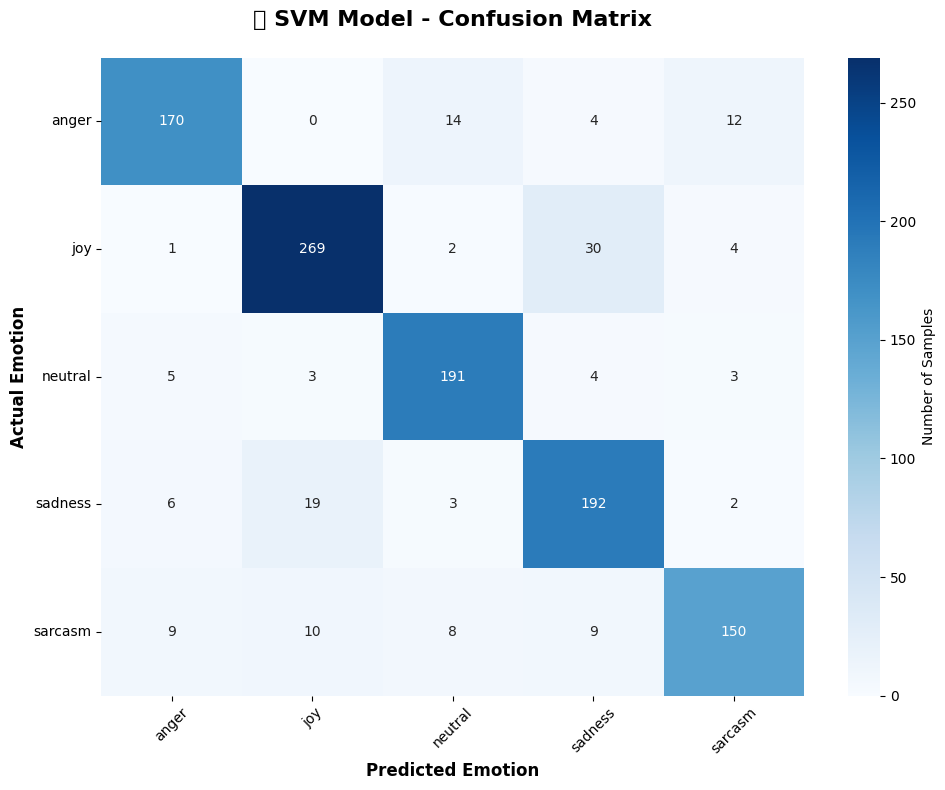


🎯 Per-Class Performance:
   anger     : 85.00%
   joy       : 87.91%
   neutral   : 92.72%
   sadness   : 86.49%
   sarcasm   : 80.65%

🎯 Per-Class F1 Scores:
   anger     : 0.8696
   joy       : 0.8863
   neutral   : 0.9009
   sadness   : 0.8330
   sarcasm   : 0.8403


In [17]:
# Confusion Matrix Visualization
print("📊 Generating Confusion Matrix...")

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred, labels=range(len(label_encoder.classes_)))

# Create heatmap
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Number of Samples'})

plt.title('🎯 SVM Model - Confusion Matrix\n', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Emotion', fontsize=12, fontweight='bold')
plt.ylabel('Actual Emotion', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Calculate per-class accuracy
print("\n🎯 Per-Class Performance:")
class_accuracy = cm.diagonal() / cm.sum(axis=1)
for i, emotion in enumerate(label_encoder.classes_):
    print(f"   {emotion:10}: {class_accuracy[i]:.2%}")

# Calculate per-class F1 scores (this will work since f1_score is imported)
print("\n🎯 Per-Class F1 Scores:")
f1_scores = f1_score(y_test, y_pred, average=None)
for i, emotion in enumerate(label_encoder.classes_):
    print(f"   {emotion:10}: {f1_scores[i]:.4f}")

In [18]:
import joblib
import json
from datetime import datetime

# Save Model and Files
print("💾 Saving model and files...")

# Create timestamp for versioning
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save the trained model
model_filename = f'svm_emotion_model_{timestamp}.pkl'
joblib.dump(svm_model, model_filename)
print(f"✅ Model saved as: {model_filename}")

# Save the TF-IDF vectorizer
tfidf_filename = f'tfidf_vectorizer_{timestamp}.pkl'
joblib.dump(tfidf, tfidf_filename)
print(f"✅ TF-IDF vectorizer saved as: {tfidf_filename}")

# Save the label encoder
label_encoder_filename = f'label_encoder_{timestamp}.pkl'
joblib.dump(label_encoder, label_encoder_filename)
print(f"✅ Label encoder saved as: {label_encoder_filename}")

# Save stop words
stop_words_filename = f'stop_words_{timestamp}.pkl'
joblib.dump(final_stop_words, stop_words_filename)
print(f"✅ Stop words saved as: {stop_words_filename}")

# Save model metadata
metadata = {
    'model_type': 'SVM',
    'kernel': 'linear',
    'accuracy': float(accuracy),
    'f1_score': float(f1),
    'training_time_seconds': float(training_time),
    'timestamp': timestamp,
    'vocabulary_size': len(tfidf.vocabulary_),
    'classes': label_encoder.classes_.tolist(),
    'test_samples': len(X_test_cleaned),
    'train_samples': len(X_train_cleaned)
}

metadata_filename = f'model_metadata_{timestamp}.json'
with open(metadata_filename, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✅ Model metadata saved as: {metadata_filename}")

💾 Saving model and files...
✅ Model saved as: svm_emotion_model_20251129_153438.pkl
✅ TF-IDF vectorizer saved as: tfidf_vectorizer_20251129_153438.pkl
✅ Label encoder saved as: label_encoder_20251129_153438.pkl
✅ Stop words saved as: stop_words_20251129_153438.pkl
✅ Model metadata saved as: model_metadata_20251129_153438.json


In [24]:
import base64
from io import BytesIO

print("📊 Generating HTML Report...")

# Generate confusion matrix as base64
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred, labels=range(len(label_encoder.classes_)))

sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Number of Samples'})

plt.title('SVM Model - Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Emotion', fontsize=12, fontweight='bold')
plt.ylabel('Actual Emotion', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

# Convert to base64
buffer = BytesIO()
plt.savefig(buffer, format='png', dpi=300, bbox_inches='tight', facecolor='white')
buffer.seek(0)
image_base64 = base64.b64encode(buffer.getvalue()).decode()
plt.close()

confusion_matrix_html = f'<img src="data:image/png;base64,{image_base64}" alt="Confusion Matrix" style="max-width: 100%; height: auto;">'

# Create HTML content
html_content = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>SVM Emotion Classification Report</title>
    <style>
        body {{ font-family: Arial, sans-serif; margin: 40px; background-color: #f5f5f5; }}
        .container {{ max-width: 1200px; margin: 0 auto; background: white; padding: 30px; border-radius: 10px; box-shadow: 0 0 10px rgba(0,0,0,0.1); }}
        .header {{ text-align: center; background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); color: white; padding: 20px; border-radius: 10px; margin-bottom: 30px; }}
        .metrics {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(200px, 1fr)); gap: 20px; margin-bottom: 30px; }}
        .metric-card {{ background: #f8f9fa; padding: 20px; border-radius: 8px; text-align: center; border-left: 4px solid #667eea; }}
        .metric-value {{ font-size: 24px; font-weight: bold; color: #333; }}
        .metric-label {{ font-size: 14px; color: #666; }}
        .confusion-matrix {{ text-align: center; margin: 30px 0; }}
        table {{ width: 100%; border-collapse: collapse; margin: 20px 0; }}
        th, td {{ padding: 12px; text-align: center; border: 1px solid #ddd; }}
        th {{ background-color: #f2f2f2; }}
        .good {{ background-color: #d4edda; }}
        .medium {{ background-color: #fff3cd; }}
        .poor {{ background-color: #f8d7da; }}
    </style>
</head>
<body>
    <div class="container">
        <div class="header">
            <h1>🎭 SVM Emotion Classification Report</h1>
            <p>Roman Urdu Text Emotion Analysis</p>
        </div>
        
        <div class="metrics">
            <div class="metric-card">
                <div class="metric-value">{accuracy * 100:.2f}%</div>
                <div class="metric-label">Accuracy</div>
            </div>
            <div class="metric-card">
                <div class="metric-value">{f1:.4f}</div>
                <div class="metric-label">F1-Score</div>
            </div>
            <div class="metric-card">
                <div class="metric-value">{training_time:.1f}s</div>
                <div class="metric-label">Training Time</div>
            </div>
            <div class="metric-card">
                <div class="metric-value">{inference_speed:.0f}/s</div>
                <div class="metric-label">Inference Speed</div>
            </div>
        </div>

        <h2>📊 Confusion Matrix</h2>
        <div class="confusion-matrix">
            {confusion_matrix_html}
        </div>

        <!-- Rest of your HTML content remains the same -->
        <h2>🎯 Performance by Emotion</h2>
        <table>
            <thead>
                <tr>
                    <th>Emotion</th>
                    <th>Accuracy</th>
                    <th>F1-Score</th>
                    <th>Support</th>
                </tr>
            </thead>
            <tbody>
"""

# Add performance rows (your existing code)
for i, emotion in enumerate(label_encoder.classes_):
    acc_class = class_accuracy[i]
    f1_class = f1_scores[i]
    support = cm.sum(axis=1)[i]
    
    if acc_class > 0.75:
        row_class = "good"
    elif acc_class > 0.60:
        row_class = "medium"
    else:
        row_class = "poor"
    
    html_content += f"""
                <tr class="{row_class}">
                    <td><strong>{emotion}</strong></td>
                    <td>{acc_class:.2%}</td>
                    <td>{f1_class:.4f}</td>
                    <td>{support}</td>
                </tr>
"""

# Close HTML
html_content += f"""
            </tbody>
        </table>

        <h2>🔧 Model Details</h2>
        <table>
            <tr><td><strong>Model Type</strong></td><td>SVM with Linear Kernel</td></tr>
            <tr><td><strong>Vocabulary Size</strong></td><td>{len(tfidf.vocabulary_)}</td></tr>
            <tr><td><strong>Training Samples</strong></td><td>{len(X_train_cleaned)}</td></tr>
            <tr><td><strong>Test Samples</strong></td><td>{len(X_test_cleaned)}</td></tr>
            <tr><td><strong>Timestamp</strong></td><td>{timestamp}</td></tr>
        </table>

        <div style="margin-top: 40px; padding: 20px; background: #f8f9fa; border-radius: 8px; text-align: center;">
            <p><strong>Roman Urdu Emotion Classification System</strong></p>
            <p>Generated on {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}</p>
        </div>
    </div>
</body>
</html>
"""

# Save HTML report
html_filename = f'emotion.html'
with open(html_filename, 'w', encoding='utf-8') as f:
    f.write(html_content)

print(f"✅ HTML report saved as: {html_filename}")

📊 Generating HTML Report...
✅ HTML report saved as: emotion.html


In [21]:
# Final Results Summary
print("🎉 FINAL SVM MODEL SUMMARY")
print("=" * 70)

# Create a comprehensive results table
results_data = {
    'Metric': ['Overall Accuracy', 'Weighted F1-Score', 'Weighted Precision', 'Weighted Recall', 
               'Training Time', 'Inference Speed', 'Vocabulary Size', 'Test Samples'],
    'Value': [f"{accuracy*100:.2f}%", f"{f1:.4f}", f"{precision:.4f}", f"{recall:.4f}", 
              f"{training_time:.2f} sec", f"{inference_speed:.0f} sent/sec", 
              f"{len(tfidf.vocabulary_)}", f"{len(X_test_cleaned)}"]
}

results_df = pd.DataFrame(results_data)
print("\n📊 Performance Metrics:")
print(results_df.to_string(index=False))

print(f"\n👥 Team Member Assignment:")
print("   Member 1: SVM (Baseline) - THIS IMPLEMENTATION")

print(f"\n📁 Dataset Used: JazbaatAI_data")
print(f"   Total Samples: {len(df)}")
print(f"   Training Samples: {len(X_train_cleaned)}")
print(f"   Testing Samples: {len(X_test_cleaned)}")
print(f"   Train-Test Split: 80%-20%")
print(f"   Emotions: {', '.join(label_encoder.classes_)}")

print(f"\n💾 Files Generated:")
print(f"   📁 Model: {model_filename}")
print(f"   📁 TF-IDF: {tfidf_filename}")
print(f"   📁 Labels: {label_encoder_filename}")
print(f"   📁 Stop Words: {stop_words_filename}")
print(f"   📁 Metadata: {metadata_filename}")
print(f"   📁 Report: {html_filename}")

# Show best and worst performing emotions
best_emotion_idx = np.argmax(class_accuracy)
worst_emotion_idx = np.argmin(class_accuracy)

print(f"\n🏆 Best Performing Emotion:")
print(f"   {label_encoder.classes_[best_emotion_idx]}: {class_accuracy[best_emotion_idx]:.2%}")

print(f"📉 Worst Performing Emotion:")
print(f"   {label_encoder.classes_[worst_emotion_idx]}: {class_accuracy[worst_emotion_idx]:.2%}")

print(f"\n✅ SVM Training Pipeline Completed Successfully!")

🎉 FINAL SVM MODEL SUMMARY

📊 Performance Metrics:
            Metric         Value
  Overall Accuracy        86.79%
 Weighted F1-Score        0.8678
Weighted Precision        0.8692
   Weighted Recall        0.8679
     Training Time     13.19 sec
   Inference Speed 1491 sent/sec
   Vocabulary Size          9126
      Test Samples          1120

👥 Team Member Assignment:
   Member 1: SVM (Baseline) - THIS IMPLEMENTATION

📁 Dataset Used: JazbaatAI_data
   Total Samples: 5599
   Training Samples: 4479
   Testing Samples: 1120
   Train-Test Split: 80%-20%
   Emotions: anger, joy, neutral, sadness, sarcasm

💾 Files Generated:
   📁 Model: svm_emotion_model_20251129_153438.pkl
   📁 TF-IDF: tfidf_vectorizer_20251129_153438.pkl
   📁 Labels: label_encoder_20251129_153438.pkl
   📁 Stop Words: stop_words_20251129_153438.pkl
   📁 Metadata: model_metadata_20251129_153438.json
   📁 Report: emotion_classification_report_20251129_153447.html

🏆 Best Performing Emotion:
   neutral: 92.72%
📉 Worst Perfo